# Document parsing with GLM-OCR and OpenVINO

[GLM-OCR](https://huggingface.co/zai-org/GLM-OCR) is a compact 0.9B-parameter OCR
vision-language model released by Zhipu AI. It pairs a CogViT-derived vision encoder
with a GLM-4.5-style text decoder and is specialised for three document-parsing
tasks: **Text Recognition**, **Formula Recognition**, and **Table Recognition**.

<img width="1071" height="405" alt="image" src="https://github.com/user-attachments/assets/3394dd11-cf7f-43d9-a77e-920169d0f099" />

In this tutorial we convert GLM-OCR to OpenVINO IR via optimum-intel, optionally
compress its weights to INT4 with [NNCF](https://github.com/openvinotoolkit/nncf),
and run inference on Intel CPU / integrated GPU / Arc GPU. A streaming Gradio demo
mirroring the official [GLM-OCR-Demo](https://huggingface.co/spaces/prithivMLmods/GLM-OCR-Demo)
Space is provided as well, plus a full document-parsing pipeline that combines
PP-DocLayoutV3 (layout detection) with GLM-OCR (region recognition).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Convert and Optimize model](#Convert-and-Optimize-model)
  - [Compress model weights to 4-bit](#Compress-model-weights-to-4-bit)
- [Run OpenVINO model](#Run-OpenVINO-model)
  - [Select inference device](#Select-inference-device)
- [OCR inference — Text / Formula / Table](#OCR-inference)
- [PP-DocLayoutV3 + GLM-OCR pipeline](#PP-DocLayoutV3-+-GLM-OCR-pipeline)
- [Interactive demo](#Interactive-demo)


⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with
OpenVINO and is using a custom branch of optimum-intel. It may be fully
supported and validated in the future.

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/glm-ocr/glm-ocr.ipynb" />

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

GLM-OCR lives in `transformers==5.5.4` and relies on the `GLM-OCR`
branch of the [openvino-dev-samples/optimum-intel](https://github.com/openvino-dev-samples/optimum-intel)
fork.


In [ ]:
import requests
from pathlib import Path

if not Path("cmd_helper.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py")
    Path("cmd_helper.py").write_text(r.text, encoding="utf-8")

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    Path("notebook_utils.py").write_text(r.text, encoding="utf-8")

# gradio_helper.py and pp_doclayout_v3_helper.py ship alongside this notebook;
# no download needed when running from the repository checkout.

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("glm-ocr.ipynb")

In [ ]:
%pip uninstall -q -y optimum optimum-intel optimum-onnx

from notebook_utils import pip_install

pip_install("-q", "torch>=2.8", "torchvision", "--extra-index-url", "https://download.pytorch.org/whl/cpu")
pip_install("-q", "git+https://github.com/openvino-dev-samples/optimum-intel.git@GLM-OCR")
pip_install("-q", "transformers==5.5.4")
pip_install("-q", "openvino>=2026.1.0", "nncf>=2.17.0")
pip_install("-q", "gradio>=5.25.0", "Pillow>=10")

# Fetch the sample OCR images used in the OCR inference and pipeline cells.
# They are hosted as GitHub user-attachments rather than bundled in the repo.
from gradio_helper import download_example_assets

download_example_assets()

Note: you may need to restart the kernel to use updated packages.


[WindowsPath('D:/openvino_notebooks/notebooks/glm-ocr/ocr_text_sample.png'),
 WindowsPath('D:/openvino_notebooks/notebooks/glm-ocr/ocr_formula_sample.png'),
 WindowsPath('D:/openvino_notebooks/notebooks/glm-ocr/ocr_table_sample.png'),
 WindowsPath('D:/openvino_notebooks/notebooks/glm-ocr/ocr_doc_sample.png')]

## Convert and Optimize model
[back to top ⬆️](#Table-of-contents:)

[Optimum Intel](https://huggingface.co/docs/optimum/intel/index) exposes a command-line
interface to export HuggingFace models to OpenVINO IR. For GLM-OCR we use the
`image-text-to-text` task, which produces four IR submodels: the vision patch
embedder, the vision-transformer + merger, the text-embedding lookup, and the
stateful language-model decoder.

```bash
optimum-cli export openvino --model zai-org/GLM-OCR --task image-text-to-text --weight-format int4 GLM-OCR/INT4
```

### Compress model weights to 4-bit
[back to top ⬆️](#Table-of-contents:)

The 0.9B-parameter text decoder dominates the footprint, so INT4 weight
compression yields a meaningful size reduction with negligible quality loss
on OCR tasks. We use NNCF through `optimum-cli`'s `--weight-format int4
--group-size 128 --ratio 1.0` options.


In [3]:
import ipywidgets as widgets

model_id = "zai-org/GLM-OCR"

to_compress = widgets.Checkbox(
    value=True,
    description="Weight compression to INT4",
    disabled=False,
)
to_compress

Checkbox(value=True, description='Weight compression to INT4')

In [4]:
from pathlib import Path

model_base_dir = Path(model_id.split("/")[-1])  # "GLM-OCR"
additional_args = {"task": "image-text-to-text"}

if to_compress.value:
    model_dir = model_base_dir / "INT4"
    additional_args.update({"weight-format": "int4", "group-size": "128", "ratio": "1.0"})
else:
    model_dir = model_base_dir / "FP16"
    additional_args.update({"weight-format": "fp16"})

from cmd_helper import optimum_cli

if not model_dir.exists():
    optimum_cli(model_id, model_dir, additional_args=additional_args)

print("OpenVINO IR ready at:", model_dir)

OpenVINO IR ready at: GLM-OCR\INT4


## Run OpenVINO model
[back to top ⬆️](#Table-of-contents:)

optimum-intel's `OVModelForVisualCausalLM` loads the IR that we just exported and
exposes a transformers-compatible API: `.generate()`, `.forward()`, HuggingFace
chat templates, token streamers, etc.

### Select inference device
[back to top ⬆️](#Table-of-contents:)

GLM-OCR runs well on Intel integrated GPUs and Arc GPUs; NPU inference is not
currently supported for image-text-to-text models and is therefore excluded
from the widget below.


In [5]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU', 'AUTO'), value='CPU')

In [7]:
from transformers import AutoProcessor
from optimum.intel import OVModelForVisualCausalLM

processor = AutoProcessor.from_pretrained(model_dir, trust_remote_code=True)
model = OVModelForVisualCausalLM.from_pretrained(model_dir, device=device.value)

## OCR inference
[back to top ⬆️](#Table-of-contents:)

GLM-OCR is designed around three prompts — `Text Recognition:`, `Formula
Recognition:`, and `Table Recognition:`. Below we exercise each prompt on a
bundled sample image; the code mirrors the official snippet in the
[`zai-org/GLM-OCR` model card](https://huggingface.co/zai-org/GLM-OCR).


In [8]:
import sys
from pathlib import Path
from threading import Thread

from PIL import Image
from IPython.display import display
from transformers import TextIteratorStreamer


def run_glm_ocr(image_path, prompt, max_new_tokens=1024):
    """Run GLM-OCR and stream the decoded text to stdout as it arrives.

    Returns the full decoded string once generation finishes.
    """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "url": str(image_path)},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs.pop("token_type_ids", None)

    tokenizer = processor.tokenizer if hasattr(processor, "tokenizer") else processor
    streamer = TextIteratorStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    gen_kwargs = dict(
        inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        streamer=streamer,
    )
    thread = Thread(target=model.generate, kwargs=gen_kwargs, daemon=True)
    thread.start()

    output = ""
    for piece in streamer:
        sys.stdout.write(piece)
        sys.stdout.flush()
        output += piece
    thread.join(timeout=1.0)
    sys.stdout.write("\n")
    sys.stdout.flush()
    return output

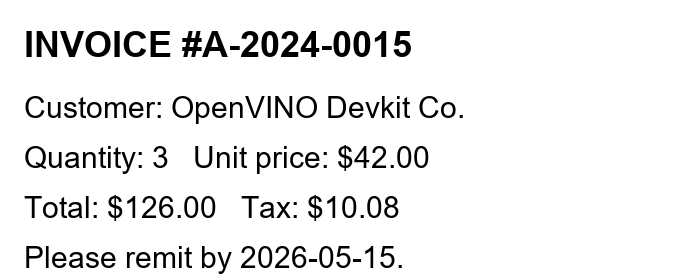

INVOICE #A-2024-0015

Customer: OpenVINO Devkit Co.
Quantity: 3 Unit price: $42.00
Total: $126.00 Tax: $10.08
Please remit by 2026-05-15.


'INVOICE #A-2024-0015\n\nCustomer: OpenVINO Devkit Co.\nQuantity: 3 Unit price: $42.00\nTotal: $126.00 Tax: $10.08\nPlease remit by 2026-05-15.'

In [9]:
text_image = Path("ocr_text_sample.png")
display(Image.open(text_image))
run_glm_ocr(text_image, "Text Recognition:")

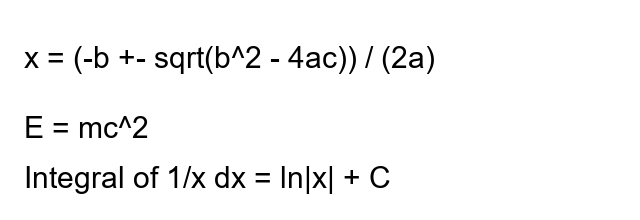

$$
\begin{array}{l} x = (- b + - \sqrt {b ^ {2} - 4 a c}) / (2 a) \\ E = m c ^ {2} \\ \mathrm {I n t e g r a l} 1 / x \mathrm {d x} = \ln | x | + C \\ \end{array}
$$


'$$\n\\begin{array}{l} x = (- b + - \\sqrt {b ^ {2} - 4 a c}) / (2 a) \\\\ E = m c ^ {2} \\\\ \\mathrm {I n t e g r a l} 1 / x \\mathrm {d x} = \\ln | x | + C \\\\ \\end{array}\n$$'

In [10]:
formula_image = Path("ocr_formula_sample.png")
display(Image.open(formula_image))
run_glm_ocr(formula_image, "Formula Recognition:")

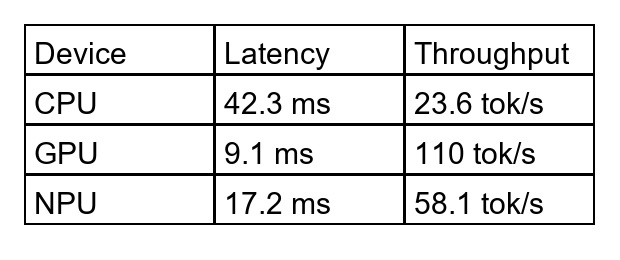

<table border="1"><tr><td>Device</td><td>Latency</td><td>Throughput</td></tr><tr><td>CPU</td><td>42.3ms</td><td>23.6tok/s</td></tr><tr><td>GPU</td><td>9.1ms</td><td>110tok/s</td></tr><tr><td>NPU</td><td>17.2ms</td><td>58.1tok/s</td></tr></table>


'<table border="1"><tr><td>Device</td><td>Latency</td><td>Throughput</td></tr><tr><td>CPU</td><td>42.3ms</td><td>23.6tok/s</td></tr><tr><td>GPU</td><td>9.1ms</td><td>110tok/s</td></tr><tr><td>NPU</td><td>17.2ms</td><td>58.1tok/s</td></tr></table>'

In [11]:
table_image = Path("ocr_table_sample.png")
display(Image.open(table_image))
run_glm_ocr(table_image, "Table Recognition:")

## PP-DocLayoutV3 + GLM-OCR pipeline
[back to top ⬆️](#Table-of-contents:)

The official GLM-OCR SDK pairs the model with PaddleOCR's **PP-DocLayoutV3**
layout detector: a document page is first split into region-level crops
(text / paragraph title / formula / table / ...) and each region is then
dispatched to GLM-OCR with the prompt that matches its class.

The helper module `pp_doclayout_v3_helper.py` ports that flow to OpenVINO:

- `export_pp_doclayout_v3()` downloads `PaddlePaddle/PP-DocLayoutV3_safetensors`
  from the HuggingFace Hub and exports it to ONNX (once). PaddlePaddle is
  **not** required — the safetensors build ships a native `transformers`
  implementation of the model.
- `LayoutDetector` compiles that ONNX straight through
  `openvino.Core().compile_model(onnx_path, device)` — no IR conversion step —
  and returns per-region bounding boxes + class names + scores.
- `draw_layout` visualises the detections on the input image.
- `run_pipeline` glues PP-DocLayout and GLM-OCR together and emits Markdown,
  preserving the reading order.

Runs on the same device as the GLM-OCR model selected above.


In [12]:
from pp_doclayout_v3_helper import export_pp_doclayout_v3, LayoutDetector

layout_dir = export_pp_doclayout_v3(output_dir="pp_doclayout_v3_ov")
detector = LayoutDetector(layout_dir, device="CPU")

66 regions detected:
  number 0.72 [740.3, 37.2, 751.5, 49.9]
  text 0.93 [417.4, 70.8, 751.8, 132.4]
  text 0.95 [65.3, 95.9, 400.9, 252.3]
  formula 0.85 [109.3, 96.8, 307.9, 112.4]
  formula 0.79 [155.3, 114.5, 195.6, 129.5]
  formula 0.92 [459.9, 140.8, 709.1, 177.4]
  formula 0.8 [69.9, 159.2, 185.2, 174.9]
  formula_number 0.69 [731.7, 150.6, 749.1, 167.0]
  formula 0.77 [223.6, 175.0, 312.7, 190.8]
  text 0.91 [418.6, 186.6, 750.4, 247.1]
  formula 0.47 [160.3, 205.3, 202.9, 220.9]
  formula 0.65 [421.1, 200.7, 439.1, 215.6]
  formula 0.53 [705.1, 203.3, 719.5, 216.7]
  formula 0.52 [728.7, 202.7, 746.8, 216.9]
  formula 0.42 [68.5, 222.1, 81.0, 236.1]
  formula 0.53 [113.2, 220.9, 152.9, 236.7]
  formula 0.4 [420.9, 220.6, 434.8, 233.5]
  formula 0.65 [466.8, 218.9, 482.7, 232.4]
  text 0.86 [430.6, 247.1, 733.3, 264.2]
  formula 0.87 [123.5, 263.9, 344.3, 281.7]


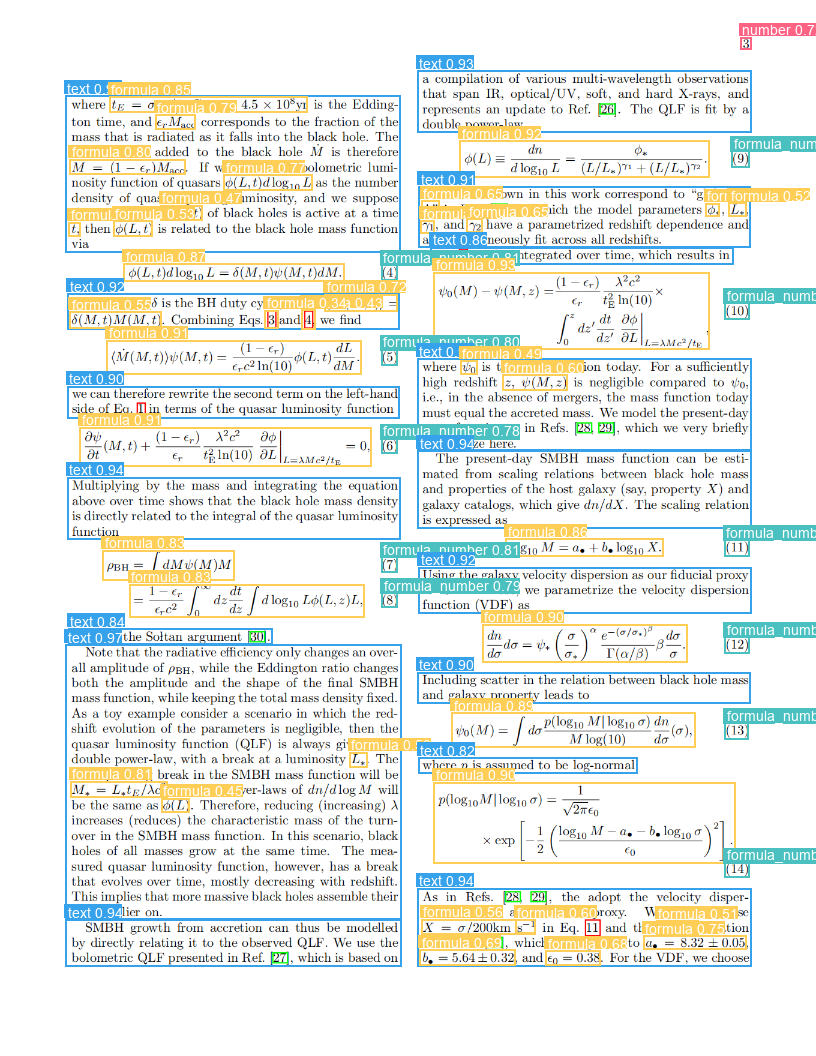

In [13]:
from pp_doclayout_v3_helper import draw_layout
from PIL import Image

doc = Image.open("ocr_doc_sample.png").convert("RGB")
detections = detector(doc, score_thr=0.3)
print(f"{len(detections)} regions detected:")
for d in detections[:20]:
    print(" ", d["class"], round(d["score"], 2), [round(x, 1) for x in d["bbox"]])
display(draw_layout(doc, detections))

In [ ]:
from pp_doclayout_v3_helper import iter_pipeline

parts = []
current_region = None
for det, chunk, final in iter_pipeline(detector, model, processor, doc, max_new_tokens=256):
    if current_region is not det:
        current_region = det
        sys.stdout.write(f"\n[{det['class']}] ")
        sys.stdout.flush()
    if chunk is not None:
        sys.stdout.write(chunk)
        sys.stdout.flush()
    if final is not None:
        parts.append(final)
sys.stdout.write("\n")


[number] 3
[text] a compilation of various multi-wavelength observations that span IR, optical/UV, and hard X-rays, and represents an update to Ref. [26]. The QLF is fit by a double power-law
[text] where $t_E = \sigma c / c \pi A G m_p = 4.5 \times 10^8 \mathrm{y r}$ is the Eddington time, and $\epsilon_e M_{\mathrm{acc}}$ corresponds to the fraction of the mass that is radiated as it falls into the black hole. The mass that is added to the black hole $M$ is therefore $M = (1 - \epsilon_e) M_{\mathrm{acc}}$. If we define the bolometric luminosity function of quasars $\delta (\phi, L) d \log_{10} L$ as the number density of quasars per log luminosity, and we suppose that a fraction $\delta (M, t)$ of black holes is active at a time $t$, then $\phi (L, t)$ is related to the black hole mass function via
[formula] $$
t _ {E} = \sigma_ {T} c / 4 \pi G m _ {p} = 4. 5 \times 1 0 ^ {8} \mathrm {y r}
$$
[formula] $$
\epsilon_ {r} M _ {\mathrm {a c c}}
$$
[formula] $$
\phi (L) \equiv \frac {d 

1

## Interactive demo
[back to top ⬆️](#Table-of-contents:)

The Gradio demo below mirrors the [prithivMLmods/GLM-OCR-Demo](https://huggingface.co/spaces/prithivMLmods/GLM-OCR-Demo)
Space: upload an image, pick a task, watch tokens stream in real time.


In [ ]:
from gradio_helper import make_demo

demo = make_demo(model, processor, detector=detector)

try:
    demo.launch(debug=False, height=800)
except Exception:
    demo.launch(debug=False, share=True, height=800)

# If you are launching remotely, specify server_name and server_port:
# demo.launch(server_name='your server name', server_port='server port number')